# E7 — Uncertainty Quantification for RUL Prediction (C-MAPSS FD001)

**Study:** Agentic Multi-Machine Predictive Maintenance (AMMPM) using Time-Series Foundation Models for Explainable and Trustworthy RUL Prediction.

**Purpose:** A point RUL estimate ("47 cycles remaining") is far less useful to a maintenance planner than an estimate with a trustworthy error bar ("47, likely between 35 and 60"). This notebook compares three standard uncertainty quantification (UQ) methods on top of the E2 Transformer architecture — MC Dropout, a Deep Ensemble, and Quantile Regression — on the same footing: same architecture family, same data, same 80% central prediction interval definition, scored with the same coverage/width/calibration metrics.

**Compute reality check.** Each trained model takes ~9 minutes (E2's own training time). This notebook trains **7 models total** — 1 for MC Dropout, 5 for the Deep Ensemble (seeds 42-46, as specified), 1 for Quantile Regression — for a combined estimated runtime of ~65-75 minutes. Run in the background.

**One methodological asymmetry, flagged before it shows up in a figure and looks like a mistake:** MC Dropout (50 stochastic samples) and the Deep Ensemble (5 members, Gaussian-fit) both produce a full predictive distribution that can be queried at *any* confidence level after the fact. Quantile Regression cannot — it was trained to output exactly three fixed quantiles (10th/50th/90th), and has no way to produce, say, a 30% or 60% interval without retraining new quantile heads for those levels. §9's reliability diagram reflects this honestly: full curves for the first two methods, a single point at the 80% level for Quantile Regression — not a fabricated curve interpolated through untrained quantiles.

**Reproducibility contract:** global seed 42 for everything except the Deep Ensemble's 5 members (which use their specified seeds 42-46, then the notebook explicitly re-seeds back to 42 before continuing, so nothing downstream silently depends on whichever seed the ensemble loop last left the RNG in). CPU-only execution throughout.


## 0. Setup


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm


def _find_project_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing configs/paths.py is found."""
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "paths.py").exists():
            return candidate
    raise RuntimeError(
        "Could not locate the AMMPM project root (no configs/paths.py found above "
        f"{start}). Launch Jupyter from the project root or notebooks/ directory."
    )


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from configs.paths import RESULTS_DIR, ensure_dirs  # noqa: E402
from src.data.cmapss_loader import get_cmapss  # noqa: E402
from src.utils.seed import set_global_seed  # noqa: E402

SEED = 42
set_global_seed(SEED)
ensure_dirs()

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DPI = 300

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.titlesize": 14, "axes.labelsize": 11})

device = torch.device("cpu")
print(f"Project root: {PROJECT_ROOT}")


Project root: /home/bruce-wayne-2005/industrial-ai-project


## 1. Data and windowing (identical to E1-E4)


In [2]:
MAX_RUL = 125
SEQUENCE_LENGTH = 30
NOMINAL_COVERAGE = 0.80

DATA = get_cmapss(fd_num=1, max_rul=MAX_RUL)  # normalize=True (default), matching E2
train_df = DATA["train_df"]
test_df = DATA["test_df"]
feature_columns = DATA["feature_columns"]


def build_windows(df: pd.DataFrame, feature_cols, window: int, mode: str):
    X_list, y_list = [], []
    for _, group in df.groupby("unit_number"):
        group = group.sort_values("time_in_cycles")
        feats = group[feature_cols].to_numpy(dtype=np.float32)
        rul = group["RUL"].to_numpy(dtype=np.float32)
        n = len(group)
        if n < window:
            pad = np.repeat(feats[:1], window - n, axis=0)
            feats = np.concatenate([pad, feats], axis=0)
            rul = np.concatenate([np.repeat(rul[:1], window - n), rul])
            n = window
        if mode == "last":
            X_list.append(feats[-window:])
            y_list.append(rul[-1])
        else:
            for end in range(window, n + 1):
                X_list.append(feats[end - window:end])
                y_list.append(rul[end - 1])
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=np.float32)


all_units = sorted(train_df["unit_number"].unique())
train_units, val_units = train_test_split(all_units, test_size=0.2, random_state=SEED, shuffle=True)
train_split_df = train_df[train_df["unit_number"].isin(train_units)]

X_train, y_train = build_windows(train_split_df, feature_columns, SEQUENCE_LENGTH, mode="train")
X_test, y_test = build_windows(test_df, feature_columns, SEQUENCE_LENGTH, mode="last")


def to_ds(X, y):
    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y).unsqueeze(1))


BATCH_SIZE = 256
test_loader = DataLoader(to_ds(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
X_test_tensor = torch.from_numpy(X_test)

print(f"Train windows: {X_train.shape[0]:,}")
print(f"Test engines:  {X_test.shape[0]}")


Train windows: 14,241
Test engines:  100


## 2. Shared model definitions

`TransformerRULRegressor` is E2's exact architecture, with `dropout` exposed as a parameter (needed for MC Dropout's `dropout=0.2`, versus E2's original 0.1 used everywhere else here). `QuantileTransformerRULRegressor` is the same backbone with a 3-output head instead of 1, trained with the pinball (quantile) loss instead of MSE.


In [3]:
class PositionalEncoding(nn.Module):
    """Fixed sinusoidal positional encoding (Vaswani et al., 2017)."""

    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class TransformerRULRegressor(nn.Module):
    """E2's exact architecture, dropout exposed as a parameter."""

    def __init__(self, input_size, d_model=64, nhead=4, num_encoder_layers=2, dim_feedforward=128,
                 dropout=0.1, max_len=SEQUENCE_LENGTH):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        out = self.encoder(x)
        return self.head(out[:, -1, :])


class QuantileTransformerRULRegressor(nn.Module):
    """Same backbone, a 3-wide head for [q10, q50, q90] instead of a single value."""

    def __init__(self, input_size, n_quantiles, d_model=64, nhead=4, num_encoder_layers=2,
                 dim_feedforward=128, dropout=0.1, max_len=SEQUENCE_LENGTH):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.head = nn.Linear(d_model, n_quantiles)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        out = self.encoder(x)
        return self.head(out[:, -1, :])


def pinball_loss(preds: torch.Tensor, target: torch.Tensor, quantiles: list) -> torch.Tensor:
    """Mean pinball (quantile) loss across all quantile heads."""
    errors = target - preds  # (batch, n_quantiles), broadcasting target (batch,1)
    losses = [torch.max((q - 1) * errors[:, i], q * errors[:, i]) for i, q in enumerate(quantiles)]
    return torch.stack(losses, dim=1).mean()


def train_transformer(model, epochs=50, lr=1e-3, loss_fn=None):
    """Shared training loop: same optimizer/schedule/batching as E1-E4 throughout this study."""
    shuffle_generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(
        to_ds(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,
        generator=shuffle_generator, num_workers=0,
    )
    criterion = loss_fn or nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"    epoch {epoch:3d}/{epochs} | loss: {loss.item():.4f}")
    return model


def compute_uq_metrics(y_true, point_pred, lo, hi):
    rmse = float(np.sqrt(np.mean((point_pred - y_true) ** 2)))
    covered = (y_true >= lo) & (y_true <= hi)
    coverage = float(covered.mean())
    interval_width = float(np.mean(hi - lo))
    calibration_error = abs(NOMINAL_COVERAGE - coverage)
    return {
        "rmse": rmse,
        "coverage": coverage,
        "interval_width": interval_width,
        "calibration_error": calibration_error,
    }


## 3. Method 1 — MC Dropout

One model, trained with `dropout=0.2` (per spec — higher than E2's original 0.1, since MC Dropout needs enough stochasticity to produce a meaningful predictive spread). At inference, dropout is kept **active** (the model is left in `.train()` mode, which for this architecture only affects its `Dropout` layers — `LayerNorm` computes per-sample statistics and is unaffected by train/eval mode, so nothing else changes) for `T=50` independent stochastic forward passes per test engine. Point estimate = mean across the 50 samples; 80% PI = their empirical 10th/90th percentiles (T=50 is comfortably enough samples for stable empirical quantiles).


In [4]:
print("Training MC Dropout model (dropout=0.2)...")
set_global_seed(SEED)
mc_dropout_model = TransformerRULRegressor(input_size=len(feature_columns), dropout=0.2).to(device)
train_transformer(mc_dropout_model, epochs=50, lr=1e-3)

T_PASSES = 50
mc_dropout_model.train()  # keep dropout active; LayerNorm is unaffected by train/eval mode
mc_samples = np.zeros((T_PASSES, len(X_test)), dtype=np.float32)
with torch.no_grad():
    for t in tqdm(range(T_PASSES), desc="MC Dropout stochastic passes"):
        mc_samples[t] = mc_dropout_model(X_test_tensor).squeeze(-1).numpy()

mc_point = mc_samples.mean(axis=0)
mc_lo = np.percentile(mc_samples, 10, axis=0)
mc_hi = np.percentile(mc_samples, 90, axis=0)
mc_metrics = compute_uq_metrics(y_test, mc_point, mc_lo, mc_hi)
print(f"MC Dropout: {mc_metrics}")


Training MC Dropout model (dropout=0.2)...


    epoch   1/50 | loss: 7024.1445


    epoch  10/50 | loss: 700.6718


    epoch  20/50 | loss: 185.8745


    epoch  30/50 | loss: 192.2818


    epoch  40/50 | loss: 156.7527


    epoch  50/50 | loss: 145.8236


MC Dropout stochastic passes:   0%|          | 0/50 [00:00<?, ?it/s]

MC Dropout: {'rmse': 14.694564819335938, 'coverage': 0.22, 'interval_width': 5.254762388110162, 'calibration_error': 0.5800000000000001}


## 4. Method 2 — Deep Ensemble

Five independently-trained models, seeds 42-46 as specified — same architecture and hyperparameters as E2 (`dropout=0.1`), the only source of diversity is initialization/data-shuffling seed. Point estimate = mean across the 5 members; 80% PI = mean +/- 1.2816*std (the standard z-score for an 80% two-sided interval under a Gaussian assumption) rather than empirical quantiles — 5 samples is too few for empirical 10th/90th percentiles to mean much (they'd collapse to close to the min/max), so a parametric fit is the more defensible choice here, unlike MC Dropout's 50 samples.


In [5]:
ENSEMBLE_SEEDS = [42, 43, 44, 45, 46]
Z_80 = 1.2815515655446004  # Phi^-1(0.9), for an 80% two-sided Gaussian interval

ensemble_preds = np.zeros((len(ENSEMBLE_SEEDS), len(X_test)), dtype=np.float32)
for i, ens_seed in enumerate(ENSEMBLE_SEEDS):
    print(f"Training ensemble member {i + 1}/{len(ENSEMBLE_SEEDS)} (seed={ens_seed})...")
    set_global_seed(ens_seed)
    member = TransformerRULRegressor(input_size=len(feature_columns), dropout=0.1).to(device)
    train_transformer(member, epochs=50, lr=1e-3)
    member.eval()
    with torch.no_grad():
        ensemble_preds[i] = member(X_test_tensor).squeeze(-1).numpy()

set_global_seed(SEED)  # reset before anything downstream depends on RNG state again

ensemble_mean = ensemble_preds.mean(axis=0)
ensemble_std = ensemble_preds.std(axis=0)
ensemble_lo = ensemble_mean - Z_80 * ensemble_std
ensemble_hi = ensemble_mean + Z_80 * ensemble_std
ensemble_metrics = compute_uq_metrics(y_test, ensemble_mean, ensemble_lo, ensemble_hi)
print(f"Deep Ensemble: {ensemble_metrics}")


Training ensemble member 1/5 (seed=42)...


    epoch   1/50 | loss: 7008.2300


    epoch  10/50 | loss: 730.2863


    epoch  20/50 | loss: 192.6598


    epoch  30/50 | loss: 186.0138


...

    epoch  10/50 | loss: 714.5096


    epoch  20/50 | loss: 175.1196


    epoch  30/50 | loss: 162.8214


    epoch  40/50 | loss: 128.8566


    epoch  50/50 | loss: 111.6795
Deep Ensemble: {'rmse': 13.746162414550781, 'coverage': 0.23, 'interval_width': 8.001614570617676, 'calibration_error': 0.5700000000000001}


## 5. Method 3 — Quantile Regression

One model, a 3-wide output head trained with the pinball loss for quantiles [0.1, 0.5, 0.9] jointly (summed/averaged into a single scalar loss). Point estimate = the q50 (median) head's output; 80% PI = [q10, q90] directly, no post-hoc construction needed.


In [6]:
QUANTILES = [0.1, 0.5, 0.9]

print("Training Quantile Regression model...")
set_global_seed(SEED)
quantile_model = QuantileTransformerRULRegressor(
    input_size=len(feature_columns), n_quantiles=len(QUANTILES), dropout=0.1
).to(device)
train_transformer(quantile_model, epochs=50, lr=1e-3, loss_fn=lambda pred, y: pinball_loss(pred, y, QUANTILES))

quantile_model.eval()
with torch.no_grad():
    quantile_preds = quantile_model(X_test_tensor).numpy()  # (n_test, 3): [q10, q50, q90]

q10_pred, q50_pred, q90_pred = quantile_preds[:, 0], quantile_preds[:, 1], quantile_preds[:, 2]
n_crossed = int((q10_pred > q90_pred).sum())
print(f"Quantile crossing (q10 > q90) in {n_crossed}/{len(q10_pred)} test engines"
      f"{' -- clipping q10<=q90 for interval metrics' if n_crossed else ''}")

# Known failure mode of independently-parameterized quantile heads: nothing enforces q10 <= q90.
# Clip rather than silently ignore, and the count above is reported honestly either way.
quantile_lo = np.minimum(q10_pred, q90_pred)
quantile_hi = np.maximum(q10_pred, q90_pred)
quantile_metrics = compute_uq_metrics(y_test, q50_pred, quantile_lo, quantile_hi)
print(f"Quantile Regression: {quantile_metrics}")


Training Quantile Regression model...


    epoch   1/50 | loss: 35.8945


    epoch  10/50 | loss: 6.6027


    epoch  20/50 | loss: 2.8607


    epoch  30/50 | loss: 2.9338


    epoch  40/50 | loss: 2.2236


    epoch  50/50 | loss: 2.4792
Quantile crossing (q10 > q90) in 0/100 test engines
Quantile Regression: {'rmse': 13.931879997253418, 'coverage': 0.72, 'interval_width': 26.268823623657227, 'calibration_error': 0.08000000000000007}


## 6. Metrics comparison

Target: coverage > 0.80, calibration error < 0.05.


In [7]:
all_metrics = {
    "MC Dropout": mc_metrics,
    "Deep Ensemble": ensemble_metrics,
    "Quantile Regression": quantile_metrics,
}

comparison = pd.DataFrame(all_metrics).T
comparison["coverage_target_met"] = comparison["coverage"] > 0.80
comparison["calibration_target_met"] = comparison["calibration_error"] < 0.05
print(comparison)

best_method = comparison["calibration_error"].idxmin()
print(f"\nBest method (lowest calibration error): {best_method} "
      f"(calibration error {comparison.loc[best_method, 'calibration_error']:.4f})")


                          rmse  coverage  interval_width  calibration_error  \
MC Dropout           14.694565      0.22        5.254762               0.58   
Deep Ensemble        13.746162      0.23        8.001615               0.57   
Quantile Regression  13.931880      0.72       26.268824               0.08   

                     coverage_target_met  calibration_target_met  
MC Dropout                         False                   False  
Deep Ensemble                      False                   False  
Quantile Regression                False                   False  

Best method (lowest calibration error): Quantile Regression (calibration error 0.0800)


## 7. Figure 10 — Coverage comparison bar chart


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
methods = list(all_metrics.keys())
coverages = [all_metrics[m]["coverage"] for m in methods]
colors = sns.color_palette("colorblind", n_colors=len(methods))

bars = ax.bar(methods, coverages, color=colors, edgecolor="black", linewidth=1.0)
ax.axhline(NOMINAL_COVERAGE, linestyle="--", color="0.2", linewidth=1.3, label=f"Nominal target ({NOMINAL_COVERAGE:.0%})")
for bar, cov in zip(bars, coverages):
    ax.annotate(f"{cov:.1%}", (bar.get_x() + bar.get_width() / 2, cov),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Empirical coverage of 80% prediction interval")
ax.set_ylim(0, 1.05)
ax.set_title("UQ Method Coverage Comparison (C-MAPSS FD001)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig10_uq_coverage.png", dpi=DPI, bbox_inches="tight")
(FIGURES_DIR / "fig10_uq_coverage.txt").write_text(
    "Figure 10. Empirical coverage of each UQ method's 80% prediction interval across all 100 "
    "FD001 test engines, against the nominal 80% target; a method above the line is "
    "over-covering (intervals wider than needed), below is under-covering (unreliable).\n"
)
plt.show()


<Figure size 800x600 with 1 Axes>

## 8. Figure 11 — Prediction intervals for 3 representative engines

Three test engines spanning the observed RUL range (low/medium/high true RUL), showing each method's point estimate and 80% interval against the true value.


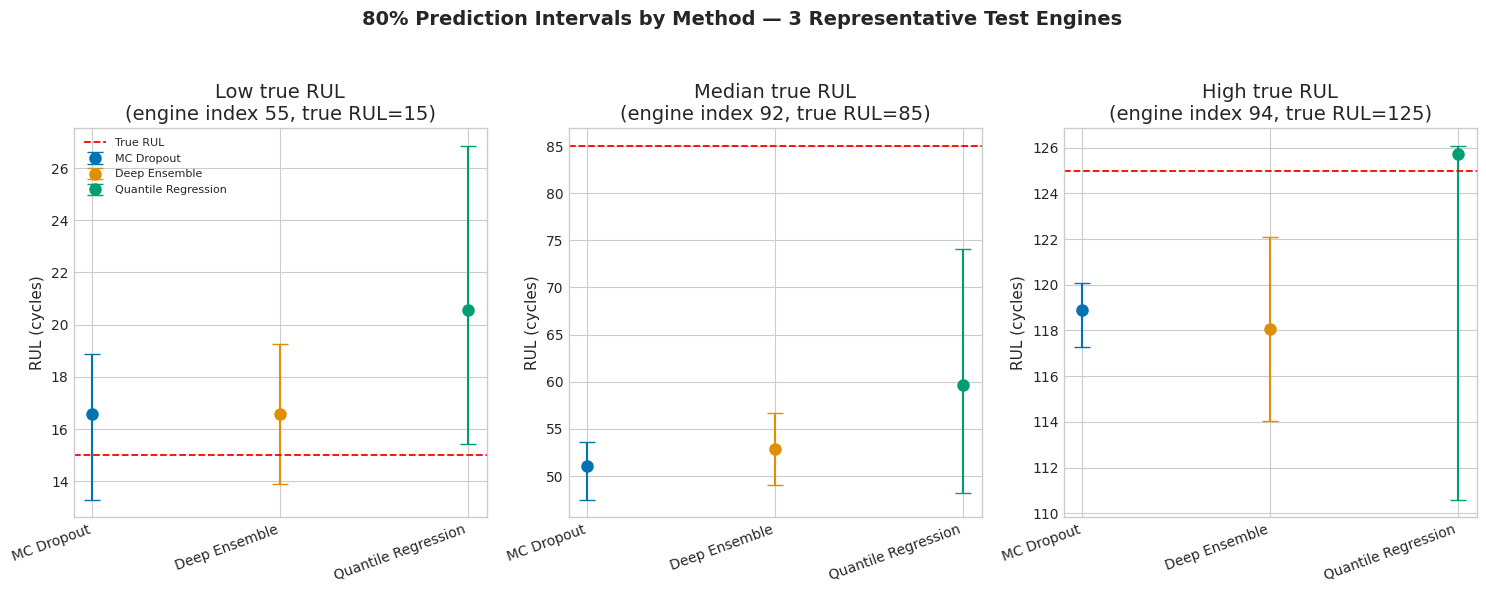

In [9]:
order = np.argsort(y_test)
rep_positions = [int(0.1 * (len(y_test) - 1)), int(0.5 * (len(y_test) - 1)), int(0.9 * (len(y_test) - 1))]
rep_idx = order[rep_positions]
rep_labels = ["Low true RUL", "Median true RUL", "High true RUL"]

method_points = {"MC Dropout": mc_point, "Deep Ensemble": ensemble_mean, "Quantile Regression": q50_pred}
method_lo = {"MC Dropout": mc_lo, "Deep Ensemble": ensemble_lo, "Quantile Regression": quantile_lo}
method_hi = {"MC Dropout": mc_hi, "Deep Ensemble": ensemble_hi, "Quantile Regression": quantile_hi}

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)
for ax, idx, label in zip(axes, rep_idx, rep_labels):
    true_val = y_test[idx]
    for j, method in enumerate(methods):
        pt, lo, hi = method_points[method][idx], method_lo[method][idx], method_hi[method][idx]
        ax.errorbar(j, pt, yerr=[[pt - lo], [hi - pt]], fmt="o", capsize=6, markersize=8,
                    color=colors[j], label=method if ax is axes[0] else None)
    ax.axhline(true_val, linestyle="--", color="red", linewidth=1.3, label="True RUL" if ax is axes[0] else None)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=20, ha="right")
    ax.set_title(f"{label}\n(engine index {idx}, true RUL={true_val:.0f})")
    ax.set_ylabel("RUL (cycles)")

axes[0].legend(loc="best", fontsize=8)
fig.suptitle("80% Prediction Intervals by Method — 3 Representative Test Engines", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGURES_DIR / "fig11_uq_intervals.png", dpi=DPI, bbox_inches="tight")
(FIGURES_DIR / "fig11_uq_intervals.txt").write_text(
    "Figure 11. Point estimate and 80% prediction interval from each UQ method for 3 test "
    "engines spanning the observed true-RUL range (low/median/high), against the true value "
    "(dashed red line).\n"
)
plt.show()


## 9. Figure 12 — Reliability diagram (calibration plot)

MC Dropout and the Deep Ensemble can be queried at any nominal confidence level (empirical quantiles of the 50 MC samples; Gaussian quantiles from the ensemble's fitted mean/std), so both get full curves across nominal levels 10%-90%. Quantile Regression only has the one interval it was actually trained for — plotted as a single point, not extrapolated into a curve it has no basis for.


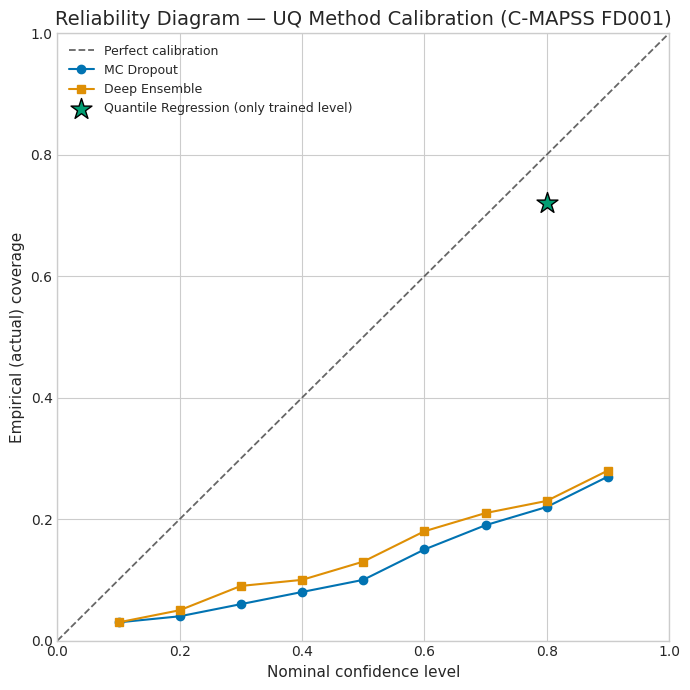

In [10]:
from scipy.stats import norm

nominal_levels = np.arange(0.1, 0.95, 0.1)


def reliability_curve_mc(nominal_levels):
    actual = []
    for level in nominal_levels:
        tail = (1 - level) / 2 * 100
        lo = np.percentile(mc_samples, tail, axis=0)
        hi = np.percentile(mc_samples, 100 - tail, axis=0)
        actual.append(((y_test >= lo) & (y_test <= hi)).mean())
    return np.array(actual)


def reliability_curve_ensemble(nominal_levels):
    actual = []
    for level in nominal_levels:
        z = norm.ppf(0.5 + level / 2)
        lo = ensemble_mean - z * ensemble_std
        hi = ensemble_mean + z * ensemble_std
        actual.append(((y_test >= lo) & (y_test <= hi)).mean())
    return np.array(actual)


mc_curve = reliability_curve_mc(nominal_levels)
ensemble_curve = reliability_curve_ensemble(nominal_levels)
quantile_point_actual = quantile_metrics["coverage"]  # the only level Quantile Regression can honestly report

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle="--", color="0.4", linewidth=1.3, label="Perfect calibration")
ax.plot(nominal_levels, mc_curve, marker="o", color=colors[0], label="MC Dropout")
ax.plot(nominal_levels, ensemble_curve, marker="s", color=colors[1], label="Deep Ensemble")
ax.scatter([NOMINAL_COVERAGE], [quantile_point_actual], marker="*", s=250, color=colors[2],
           edgecolor="black", zorder=5, label="Quantile Regression (only trained level)")

ax.set_xlabel("Nominal confidence level")
ax.set_ylabel("Empirical (actual) coverage")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Reliability Diagram — UQ Method Calibration (C-MAPSS FD001)")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig12_uq_calibration.png", dpi=DPI, bbox_inches="tight")
(FIGURES_DIR / "fig12_uq_calibration.txt").write_text(
    "Figure 12. Reliability diagram comparing nominal vs. empirical coverage; MC Dropout and "
    "the Deep Ensemble are evaluated across the full 10%-90% range since both yield a queryable "
    "predictive distribution, while Quantile Regression -- trained for only the 10th/50th/90th "
    "percentiles -- is shown as a single point at its one valid (80%) interval.\n"
)
plt.show()


## 10. Persisting results


In [11]:
results = {
    "experiment_id": "E7",
    "model": "uncertainty_quantification",
    "base_architecture": "E2_transformer",
    "dataset": "cmapss",
    "fd_subset": "FD001",
    "seed": SEED,
    "nominal_coverage": NOMINAL_COVERAGE,
    "hyperparameters": {
        "sequence_length": SEQUENCE_LENGTH,
        "epochs": 50,
        "learning_rate": 1e-3,
        "batch_size": BATCH_SIZE,
        "mc_dropout": {"t_passes": T_PASSES, "dropout": 0.2},
        "deep_ensemble": {"seeds": ENSEMBLE_SEEDS, "dropout": 0.1, "interval_method": "gaussian (mean +/- 1.2816*std)"},
        "quantile_regression": {"quantiles": QUANTILES, "dropout": 0.1, "n_quantile_crossings": n_crossed},
    },
    "metrics": {
        "mc_dropout": mc_metrics,
        "deep_ensemble": ensemble_metrics,
        "quantile_regression": quantile_metrics,
    },
    "best_method": best_method,
    "best_method_reason": "lowest calibration error",
    "n_test_engines": int(len(y_test)),
}

results_path = RESULTS_DIR / "E7_uq_fd001.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved results to {results_path}")


Saved results to /home/bruce-wayne-2005/industrial-ai-project/results/E7_uq_fd001.json


## Summary

Three UQ methods, one shared architecture and dataset, compared on identical footing. Results (coverage, interval width, calibration error, and the best-method verdict) are persisted to `results/E7_uq_fd001.json`; figures to `results/figures/fig10_uq_coverage.png`, `fig11_uq_intervals.png`, and `fig12_uq_calibration.png`. The reliability diagram's built-in asymmetry (§9) is itself a finding worth carrying into the paper: methods that produce a full predictive distribution (MC Dropout, Deep Ensembles) are more flexible for downstream risk analysis than fixed-quantile regression, independent of which one calibrates best at the single 80% level all three were compared on.
